In [1]:
import sys
sys.path.insert(0, '../') # Trick to import code from parent folder
import cmip6_archive as ca
import numpy as np
import datetime
import xarray as xr

import matplotlib.pyplot as plt
from cartopy import crs as ccrs
import colormaps as cmaps
from plot_utils import plot_panel

# Figure S3
### Growing-season 90th-percentile threshold of reference evapotranspiration (ETos) from the historical simulations of the eight CMIP6 models.
Thresholds were calculated separately for each model over 1981–2000 using a centered 15-day moving window.

In [2]:
def gs_doy_mask(hemisphere):
    """Mask with 365 values, True at position i if day of year i in the growing season in that hemisphere, false otherwise."""
    m = np.zeros(365, dtype=bool)
    for d in range(365):
        mo = (datetime.date(2001, 1, 1) + datetime.timedelta(days=d)).month
        m[d] = (mo in (4, 5, 6, 7, 8, 9, 10)) if hemisphere == "NH" \
               else (mo in (1, 2, 3, 4, 10, 11, 12))
    return m

def gs_mean(da):
    """da: DataArray with dims including 'lat' and 'dayofyear' (365).
    Returns da averaged over the growing season (NH: Apr-Oct, SH: Oct-Apr)."""
    nh_mask = xr.DataArray(gs_doy_mask("NH"), dims="dayofyear", coords={"dayofyear": da.dayofyear})
    sh_mask = xr.DataArray(gs_doy_mask("SH"), dims="dayofyear", coords={"dayofyear": da.dayofyear})

    gs_mask = xr.where(da.lat >= 0, nh_mask, sh_mask)   # broadcasts to (lat, dayofyear)
    return da.where(gs_mask).mean("dayofyear", skipna=True)

In [3]:
model_p90_gs = {}
for model in ca.MODELS:
    # Find growing-season mean of daily 90th percentile of ET0
    ds = ca.PERCENTILES_ARCHIVE.open(model=model, exp=None)
    mean_p90_gs = gs_mean(ds["ET0"]).rename("mean_p90_gs")
    mean_p90_gs.attrs = {"units": "mm day-1",
                        "long_name": "growing-season mean of daily 90th percentile of ET0"}

    # Mask out grid cells with < 5% land
    land_area_fraction = ca.LAND_MASKS_ARCHIVE.open(model=model, exp='piControl')['sftlf']
    mask = (land_area_fraction >= 5).values
    mean_p90_gs = mean_p90_gs.where(mask)
    
    # Add to dict
    model_p90_gs[model] = mean_p90_gs.load()

print(f"✅ Calculated growing-season mean of daily 90th percentile of ET0 for {len(ca.MODELS)} models")

✅ Calculated growing-season mean of daily 90th percentile of ET0 for 8 models


In [4]:
# Create array with all p90 values from the 8 models
all_vals = []
for m, da in model_p90_gs.items():
    nlat, nlon = da.shape
    vals_1d = da.values.reshape(nlat*nlon)
    all_vals.append(vals_1d)
land_vals = np.concat(all_vals)
land_vals = land_vals[~np.isnan(land_vals)] # Remove NaNs

# Find 98th percentile of all values
p98 = float(np.percentile(land_vals, 98))
VMIN, VMAX = 0.0, round(p98 * 2) / 2
print(f"p90 GS land range: p2={np.percentile(land_vals,2):.2f} "
      f"p50={np.percentile(land_vals,50):.2f} p98={p98:.2f} -> vmax={VMAX} mm/day")


p90 GS land range: p2=0.01 p50=2.96 p98=10.21 -> vmax=10.0 mm/day


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/wor

  ✓ png/FigureS3.png
  ✓ pdf/FigureS3.pdf


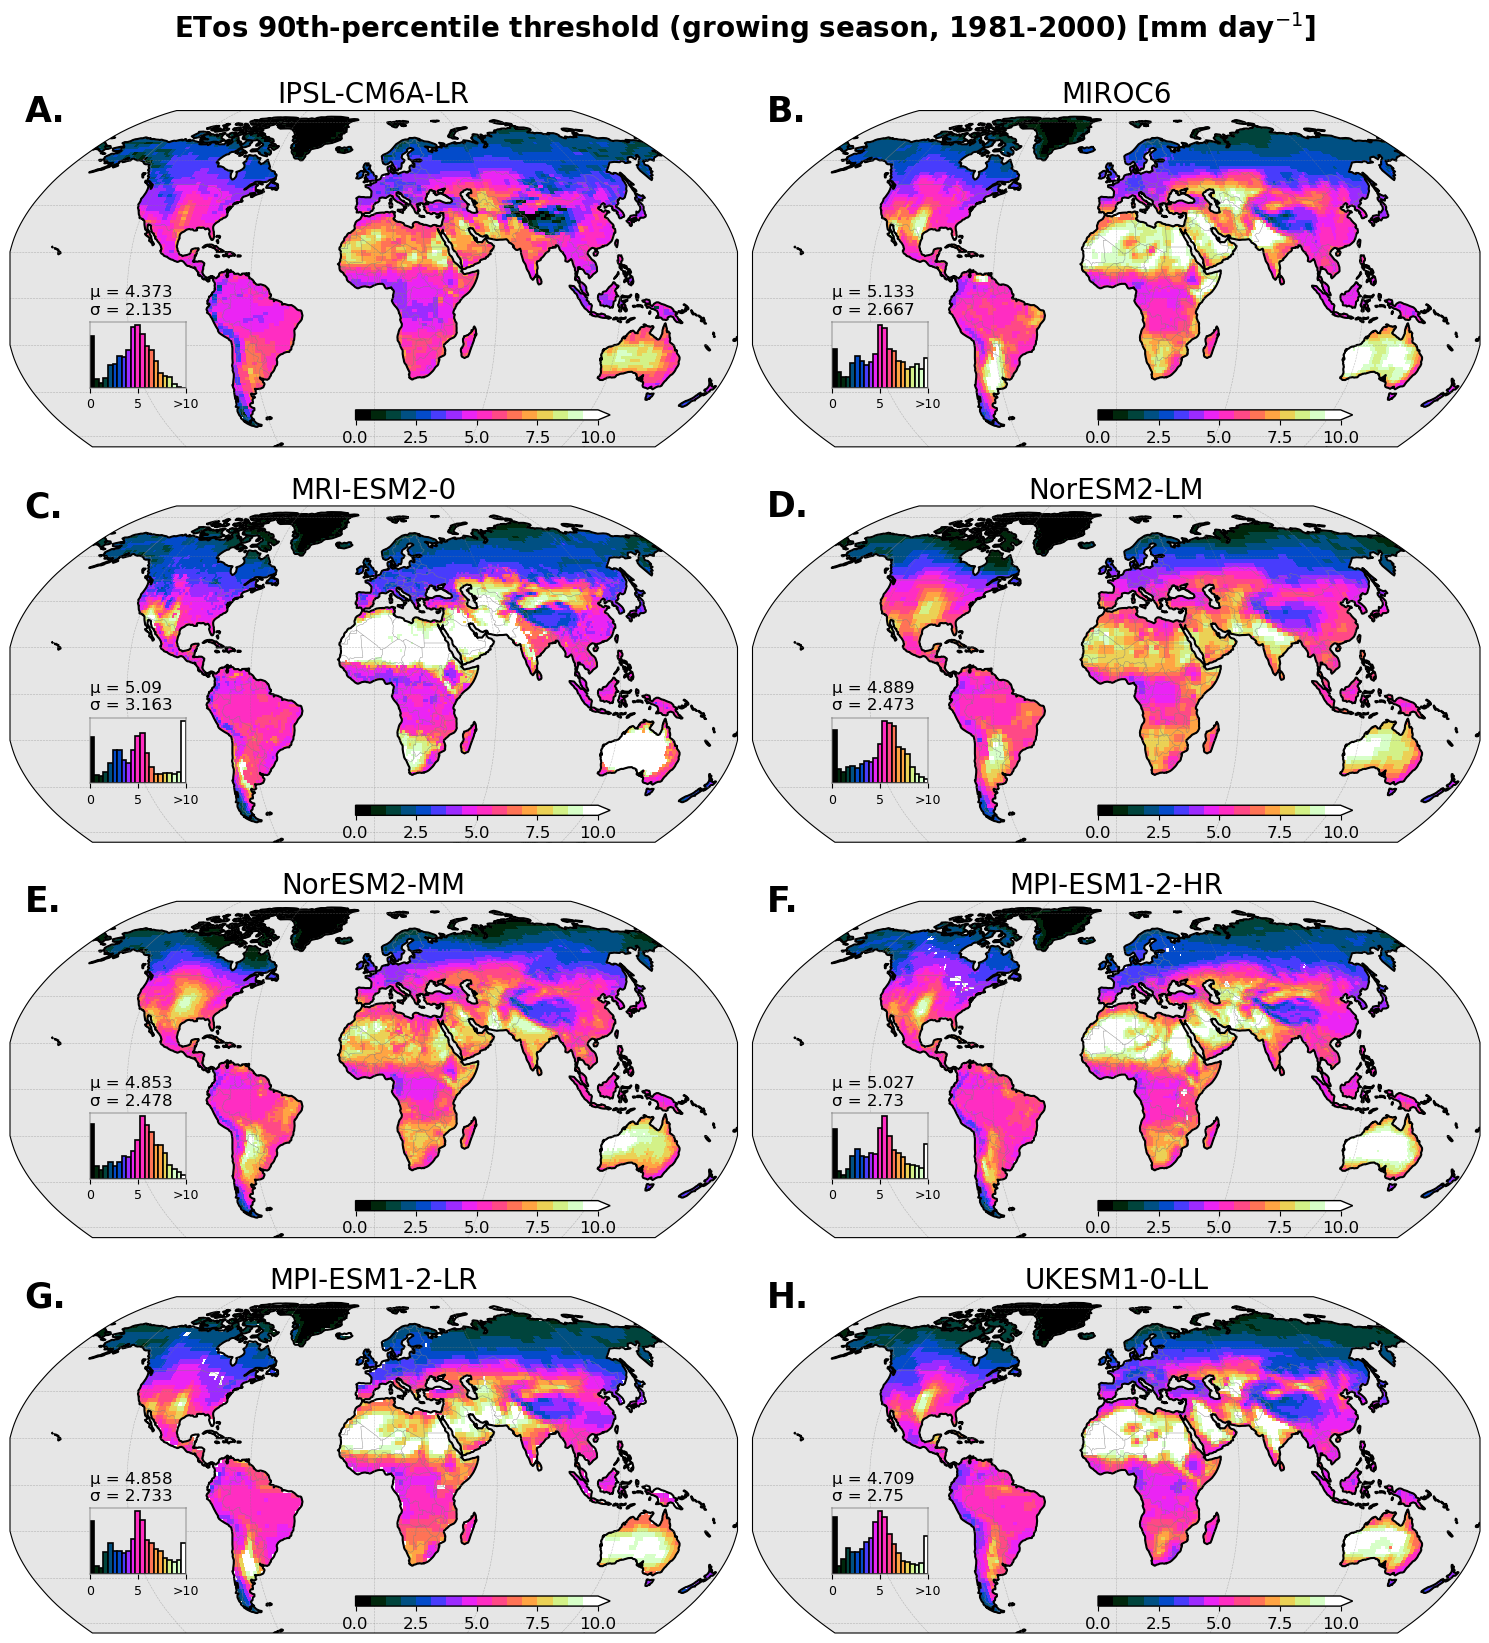

In [5]:
#  4x2 subplot
fig, axes = plt.subplots(
    4, 2,
    figsize=(15, 17),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

CMAP = cmaps.cubehelix3_16

labels = ["A.", "B.", "C.", "D.", "E.", "F.", "G.", "H."]

for i, label, model in zip(np.arange(8), labels, ca.MODELS):
    plot_panel(
        axes[i],
        model_p90_gs[model],
        title=model,
        vmin=VMIN,
        vmax=VMAX,
        cmap=CMAP,
        extend="max", 
        label=label,
        anom_type="absolute",
    )

suptitle = r"ETos 90th-percentile threshold (growing season, 1981-2000) [mm day$^{-1}$]" + "\n"
fig.suptitle(suptitle, fontsize=20, fontweight="bold")
plt.tight_layout()

# Save as png and pdf
for ext in ["png", "pdf"]:
        filename = f"{ext}/FigureS3.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")

plt.show()